- DataSet From Kaggele

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split, GridSearchCV
from scipy.cluster.hierarchy import dendrogram, linkage
import pickle


In [2]:
df = pd.read_csv('mcus.csv')

In [3]:
df.head()

,Customer ID,Age,Gender,Annual Income,Spending Score
0,d410ea53-6661-42a9-ad3a-f554b05fd2a7,30,Male,151479,89
1,1770b26f-493f-46b6-837f-4237fb5a314e,58,Female,185088,95
2,e81aa8eb-1767-4b77-87ce-1620dc732c5e,62,Female,70912,76
3,9795712a-ad19-47bf-8886-4f997d6046e3,23,Male,55460,57
4,64139426-2226-4cd6-bf09-91bce4b4db5e,24,Male,153752,76


In [4]:

# -------------------- PREPROCESSING --------------------
# Encode Gender
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])

# Select features
features = ['Gender', 'Age', 'Annual Income', 'Spending Score']
X = df[features]

# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [5]:

# -------------------- PCA --------------------
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# -------------------- KMEANS CLUSTERING --------------------
kmeans = KMeans(n_clusters=5, random_state=42)
df['KMeans_Cluster'] = kmeans.fit_predict(X_scaled)

# -------------------- PCA CLUSTERING --------------------
df['PCA_Cluster'] = KMeans(n_clusters=5, random_state=42).fit_predict(X_pca)


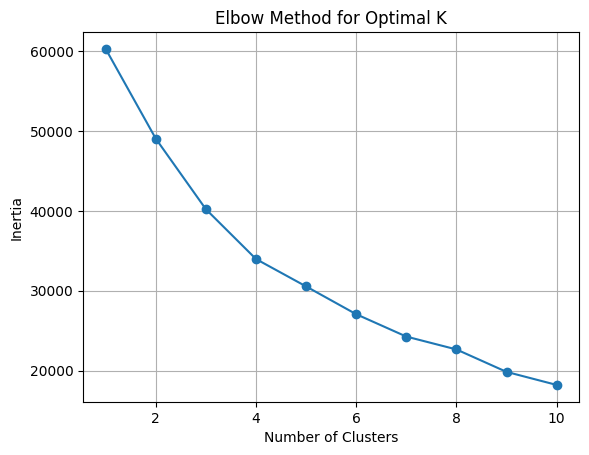

In [6]:

# --------------------------- KMeans Clustering ---------------------------
# Elbow Method to determine optimal number of clusters
inertia = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure()
plt.plot(range(1, 11), inertia, marker='o')
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.grid(True)
plt.show()


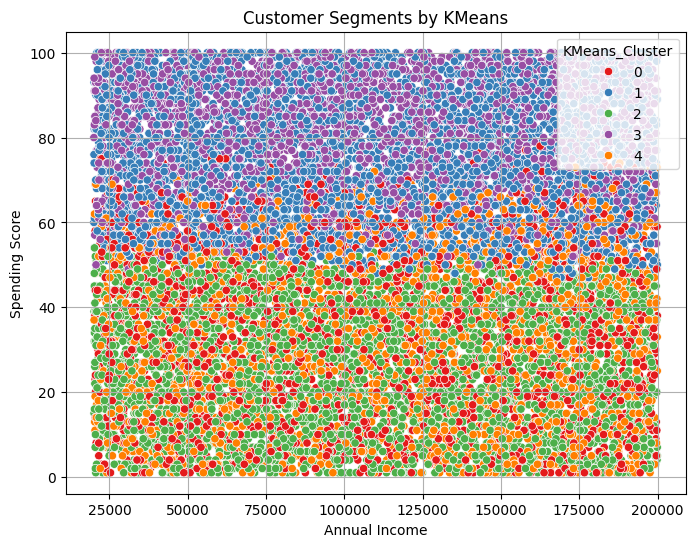

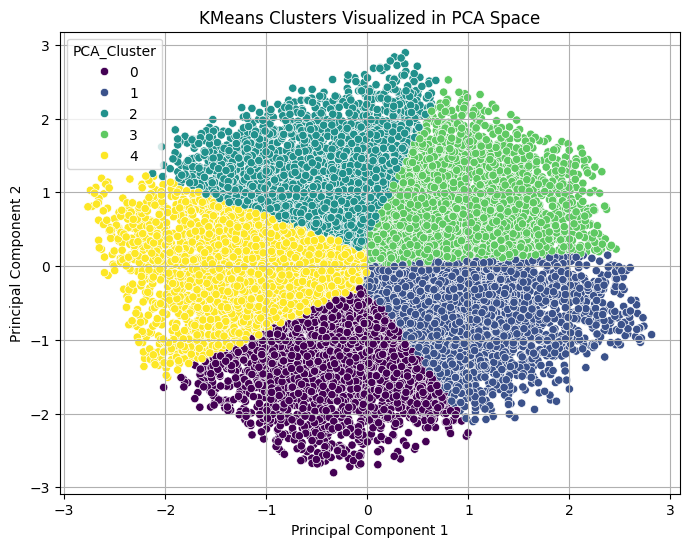

In [7]:

# -------------------- CLUSTER VISUALIZATIONS --------------------
# KMeans on original features
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Annual Income', y='Spending Score', hue='KMeans_Cluster', data=df, palette='Set1')
plt.title("Customer Segments by KMeans")
plt.grid(True)
plt.show()

# KMeans on PCA features
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df['PCA_Cluster'], palette='viridis')
plt.title("KMeans Clusters Visualized in PCA Space")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)
plt.show()

In [ ]:

# ---------------------- Hierarchical Clustering ----------------------

# Find best silhouette score between 2 to 6 clusters
silhouette_scores = {}
for n in range(2, 7):
    model = AgglomerativeClustering(n_clusters=n)
    labels = model.fit_predict(X_scaled)
    silhouette_scores[n] = silhouette_score(X_scaled, labels)

# Get best cluster count
best_n = max(silhouette_scores, key=silhouette_scores.get)
agglo_model = AgglomerativeClustering(n_clusters=best_n)
df['Agglo_Cluster'] = agglo_model.fit_predict(X_scaled)

In [ ]:

# -------------------- AGGLOMERATIVE VISUALIZATION --------------------
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Annual Income', y='Spending Score', hue='Agglo_Cluster', data=df, palette='Set2')
plt.title("Agglomerative Clustering Segments")
plt.grid(True)
plt.show()

In [ ]:
# --------------------- Dendrogram ---------------------
linked = linkage(X_scaled, method='ward')
plt.figure(figsize=(10, 5))
dendrogram(linked, truncate_mode='lastp', p=12)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Customer Index')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()



In [ ]:
# -------------------- GRID SEARCH FOR KMEANS --------------------
param_grid = {
    'n_clusters': range(2, 11),
    'init': ['k-means++'],
    'n_init': [10, 20],
    'max_iter': [300, 500]
}

grid_search = GridSearchCV(
    estimator=KMeans(random_state=42),
    param_grid=param_grid,
    scoring='neg_mean_squared_error',
    cv=3,
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_scaled)
best_model = grid_search.best_estimator_
df['Best_KMeans_Cluster'] = best_model.predict(X_scaled)

print("Best KMeans Parameters:", grid_search.best_params_)
print("Best Silhouette Score:", silhouette_score(X_scaled, df['Best_KMeans_Cluster']))


In [ ]:


# --------------------- Save Models ---------------------odels Models --------------------- ---------------------
# Save the best KMeans modelt KMeans KMeans model model
with open("kmeans_model.pkl", "wb") as f:
    pickle.dump(best_model, f)

# Save the scalerhe scaler scaler
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

# Save the PCA modelodel PCA model
with open("pca_model.pkl", "wb") as f:
    pickle.dump(pca, f)

print("✅ Models trained and saved: scaler.pkl, pca_model.pkl, kmeans_model.pkl") pca_model.pkl, kmeans_model.pkl")


In [ ]:

#Data Transforming
from sklearn.preprocessing import LabelEncoder

# Label encode before using 'Gender' in any model
enc = LabelEncoder()
df['Gender'] = enc.fit_transform(df['Gender'])


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import pandas as pd

# Assuming 'df' is your DataFrame
x = df[['Gender','Age', 'Annual Income', 'Spending Score']]

# 1. Scale the features
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)  # ✅ Fit and transform on the full dataset

# 2. Fit KMeans on the scaled data
kmeans = KMeans(n_clusters=5, random_state=42)  # You can change the cluster number
kmeans.fit(x_scaled)

# 3. For predicting new input (e.g., from Streamlit)
# Make sure input_data has SAME 4 columns as x: ['Gender', 'Age', 'Annual Income', 'Spending Score']
# Example: input_data = pd.DataFrame([[1, 30, 60, 50]], columns=['Gender', 'Age', 'Annual Income', 'Spending Score'])
input_scaled = scaler.transform(df)  # ✅ Scale using the same scaler
cluster = kmeans.predict(input_scaled)[0]    # ✅ Predict using trained KMeans model

# 4. Elbow Method (to choose optimal k)
inertia = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(x_scaled)
    inertia.append(km.inertia_)

plt.plot(range(1, 11), inertia, marker='o')
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.grid(True)
plt.show()


In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Assuming X_scaled already exists
# Step 1: Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(x_scaled)

# Step 2: Visualize the PCA-transformed data
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c='gray', alpha=0.5)
plt.title("Customers Visualized in 2D using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)
plt.show()




In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(X_pca)

df['Cluster'] = clusters


# Optional: Visualize clusters in PCA space
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='viridis')
plt.title("Customer Segments (KMeans on PCA)")
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.colorbar(label="Cluster")
plt.show()

# Visualize clusters
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Annual Income', y='Spending Score',
                hue='Cluster', palette='Set1', data=df)
plt.title("Customer Segments by K-Means")
plt.show()

In [ ]:

# but we need to split DataSet First

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Select features
x = df[['Gender','Age', 'Annual Income', 'Spending Score']]

# Scale
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

# PCA for visualization only
pca = PCA(n_components=2)
X_pca = pca.fit_transform(x_scaled)




# from sklearn.model_selection import train_test_split
# x = df[['Gender','Age', 'Annual Income', 'Spending Score']]
# y = df['Cluster']
# x_train , x_test ,y_train ,y_test = train_test_split(x,y , test_size= 0.3 , random_state=42)
# x_train .shape

# pd.DataFrame(x_train)

In [ ]:

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.model_selection import GridSearchCV
from scipy.cluster.hierarchy import dendrogram, linkage


# Standardize the features
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

# --------------------------- KMEANS CLUSTERING ---------------------------

print("🔍 KMeans GridSearch for best parameters...")
kmeans_params = {
    'n_clusters': range(2, 11),
    'init': ['k-means++'],
    'n_init': [10, 20],
    'max_iter': [300, 500],
}

kmeans = KMeans(random_state=42)
grid_search_kmeans = GridSearchCV(
    estimator=kmeans,
    param_grid=kmeans_params,
    scoring='neg_mean_squared_error',  # Silhouette score needs manual tuning
    cv=3,
    verbose=1,
    n_jobs=-1
)

grid_search_kmeans.fit(x_scaled)

best_kmeans = grid_search_kmeans.best_estimator_
kmeans_labels = best_kmeans.predict(x_scaled)

print(f"✅ Best KMeans Parameters: {grid_search_kmeans.best_params_}")
print(f"✅ KMeans Silhouette Score: {silhouette_score(x_scaled, kmeans_labels):.4f}")




In [ ]:
# ---------------------- HIERARCHICAL CLUSTERING ----------------------

print("🔍 Trying Agglomerative Clustering with various cluster counts...")

sil_scores = {}
for n_clusters in range(2, 7):
    agglom = AgglomerativeClustering(n_clusters=n_clusters)
    labels = agglom.fit_predict(x_scaled)
    score = silhouette_score(x_scaled, labels)
    sil_scores[n_clusters] = score

# Find best number of clusters
best_n = max(sil_scores, key=sil_scores.get)
print(f"✅ Best Agglomerative Clustering clusters: {best_n}")
print(f"✅ Best Silhouette Score: {sil_scores[best_n]:.4f}")

# Final Agglomerative Model
agglo = AgglomerativeClustering(n_clusters=best_n)
agglo_labels = agglo.fit_predict(x_scaled)



In [ ]:
# --------------------- DENDROGRAM ---------------------

linked = linkage(x_scaled, method='ward')
plt.figure(figsize=(10, 5))
dendrogram(linked, truncate_mode='lastp', p=12)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Customer Index')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()

In [ ]:

# --------------------- CLUSTER VISUALIZATION ---------------------

# Add cluster labels to original dataframe
df['KMeans_Cluster'] = kmeans_labels
df['Agglo_Cluster'] = agglo_labels

# KMeans cluster plot
sns.scatterplot(data=df, x='Annual Income', y='Spending Score', hue='KMeans_Cluster', palette='tab10')
plt.title("KMeans Customer Segments")
plt.show()

# Agglomerative cluster plot
sns.scatterplot(data=df, x='Annual Income', y='Spending Score', hue='Agglo_Cluster', palette='Set2')
plt.title("Hierarchical (Agglomerative) Customer Segments")
plt.show()


In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(X_pca)

df['Cluster'] = clusters


In [ ]:
import pandas as pd
import pickle
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans


# Save the best KMeans model
with open("kmeans_model.pkl", "wb") as f:
    pickle.dump(best_kmeans, f)

# Save the scaler as well
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)


with open("pca_model.pkl", "wb") as f:
    pickle.dump(pca, f)


print("✅ Models trained and saved: scaler.pkl, pca_model.pkl, kmeans_model.pkl")


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Assuming 'df' is your DataFrame as defined in the previous code.
x = df[['Age', 'Annual Income', 'Spending Score']]
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

# Find optimal number of clusters (Elbow Method)
inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(x_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 11), inertia, marker='o')
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.grid(True)
plt.show()

In [ ]:

# Fit KMeans with optimal k (let’s assume 5)
kmeans = KMeans(n_clusters=5, random_state=42)
df['Cluster'] = kmeans.fit_predict(x_scaled)

# Visualize clusters
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Annual Income', y='Spending Score',
                hue='Cluster', palette='Set1', data=df)
plt.title("Customer Segments by K-Means")
plt.show()